This notebook is to explore the covariance structure of MDTB-s1 tasks in the cerebellum. Different approaches to getting the G matrices were tried (e.g, group averaged data vs individual data)

In [1]:
from IndividualParcellation.global_config import *
import numpy as np
import torch as pt
import seaborn as sns
import matplotlib.pyplot as plt
from Functional_Fusion.dataset import DataSetMDTB
import PcmPy as pcm
import os
from scipy.stats import pearsonr


# Constants

In [2]:
base_dir = '/cifs/diedrichsen/data/FunctionalFusion'
if not os.path.exists(base_dir):
    base_dir = 'Y:/data/FunctionalFusion'

space = 'SUIT3'

In [3]:
# Check if CUDA is available
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Question 1: Does the COV group covariance matrix look like averaged individual matrices? (in the cerebellum)



# Cov-  group covariance

In [4]:
MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
task_names = info_mdtb_1.cond_name.values

Text(0.5, 1.0, 'Non cross-validated Covariance matrix of avg data')

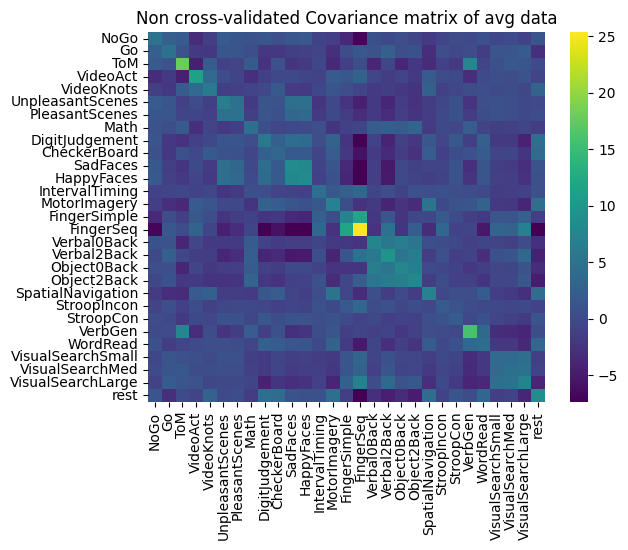

In [5]:
#remove nans
data_mdtb_s1[np.isnan(data_mdtb_s1)] = 0

# avg
avg = np.mean(data_mdtb_s1, axis=0)

#get cov matrix
cov = avg @ avg.T
sns.heatmap(cov, cmap='viridis', xticklabels=task_names, yticklabels=task_names)
plt.title('Non cross-validated Covariance matrix of avg data')

# Cov Individual covariances


Text(0.5, 1.0, 'Non cross-validated Covariance matrix  - individual subjects')

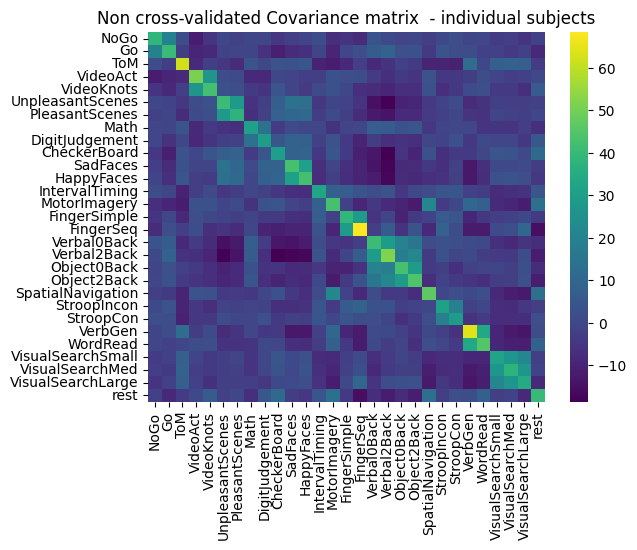

In [6]:
cov_list = []
for i in range(data_mdtb_s1.shape[0]):
    cov = data_mdtb_s1[i] @ data_mdtb_s1[i].T
    cov_list.append(cov)
covs_stacked = np.stack(cov_list, 0)
cov_mean = np.mean(covs_stacked, axis=0)

sns.heatmap(cov_mean, cmap='viridis', xticklabels=task_names, yticklabels=task_names)
plt.title('Non cross-validated Covariance matrix  - individual subjects')

Conclusions: They look similar but relationships between the tasks seem to be stronger in the individual based covariance matrix.

# Question 2: Does the 2nd moment group matrix look like averaged individual matries?


# 2nd moment group covariance

In [7]:
MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1[np.isnan(data_mdtb_s1)] = 0


Text(0.5, 1.0, 'Cross-validated Covariance matrix of avg data')

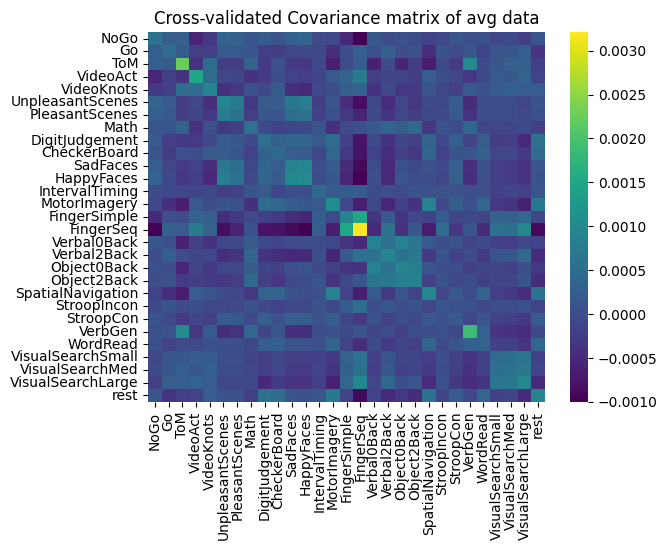

In [8]:
cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)

avg_task_matrix = np.mean(data_mdtb_s1, axis=0)
G_group,E_group = pcm.util.est_G_crossval(avg_task_matrix, cond_vec, part_vec)

sns.heatmap(G_group, cmap='viridis', xticklabels=task_names, yticklabels=task_names)
plt.title('Cross-validated Covariance matrix of avg data')


# 2nd moment individual covariances

Text(0.5, 1.0, 'Cross-validated Covariance matrix - individual subjects')

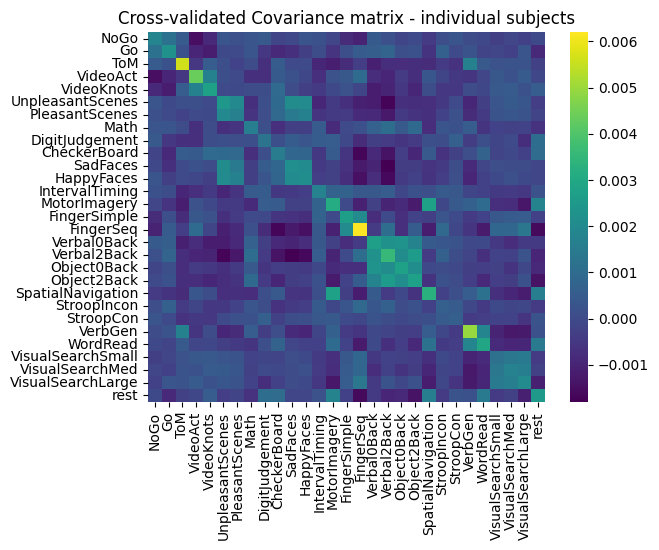

In [9]:
Gs_list = []
E_list = []
for i in range(data_mdtb_s1.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1[i], cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)

sns.heatmap(G_individuals_averaged, cmap='viridis', xticklabels=task_names, yticklabels=task_names)
plt.title('Cross-validated Covariance matrix - individual subjects')

Conclusion: They look pretty similar but again relationships stronger in individual based covariance matrix.

# plot all 4 next to each other


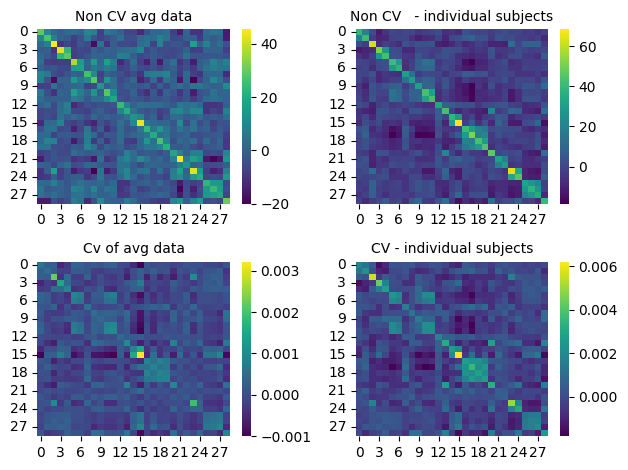

In [10]:
# make it bigger

plt.subplot(2, 2, 1)
sns.heatmap(cov, cmap='viridis')
plt.title('Non CV avg data', fontsize=10)

plt.subplot(2, 2, 2)
sns.heatmap(cov_mean, cmap='viridis')
plt.title('Non CV   - individual subjects', fontsize=10)

plt.subplot(2, 2, 3)
sns.heatmap(G_group, cmap='viridis')
plt.title('Cv of avg data', fontsize=10)

plt.subplot(2, 2, 4)
sns.heatmap(G_individuals_averaged, cmap='viridis')
plt.title('CV - individual subjects', fontsize=10)

plt.tight_layout()


# Question 3: If we regress out the group covarinace from the individual covariances and then average. Do we get anything left?
A: it does seem like tasks that activate same regions/functions are more correlated in individual matrices than in groups

In [11]:
# Compute Group-Average Pattern
group_avg_pattern = np.mean(data_mdtb_s1, axis=0)  

residuals = []
for i in range(data_mdtb_s1.shape[0]):
    individual_pattern = data_mdtb_s1[i]  
    
    # individual_pattern = beta * group_avg_pattern + residual
    individual_flat = individual_pattern.flatten()
    group_flat = group_avg_pattern.flatten()
    
    # Calculate beta
    beta = np.sum(group_flat * individual_flat) / np.sum(group_flat**2)
    
    # Compute the residual pattern
    individual_residual = individual_pattern - beta * group_avg_pattern
    
    residuals.append(individual_residual)

# Convert residuals list to a numpy array
residuals = np.stack(residuals, axis=0)  # s x n x p

#Calculate Covariance Matrix for Each Individual's Residuals
residual_covariances = []
for i in range(residuals.shape[0]):
    individual_residual = residuals[i]  # n x p
    G_s,E_s = pcm.util.est_G_crossval(individual_residual, cond_vec, part_vec)
    residual_covariances.append(G_s) 

# Avg the 2nd moments of individual residuals
residual_cov_mean = np.mean(np.stack(residual_covariances, axis=0), axis=0)



check correlation between a subjects residual and the group average, should be zero or very close to it


In [12]:
sub_res = residuals[10]
sub_res_flat = sub_res.flatten()
group_avg_flat = group_avg_pattern.flatten()

corr, _ = pearsonr(sub_res_flat, group_avg_flat)
print(corr)


-1.0191500421363742e-16


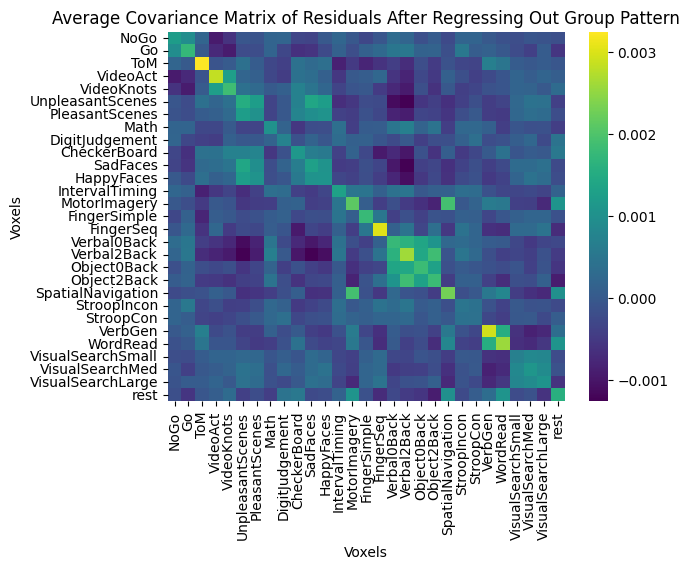

In [13]:
#plot
sns.heatmap(residual_cov_mean, xticklabels=task_names, yticklabels=task_names, cmap='viridis')
plt.title('Average Covariance Matrix of Residuals After Regressing Out Group Pattern')
plt.xlabel('Voxels')
plt.ylabel('Voxels')
plt.show()

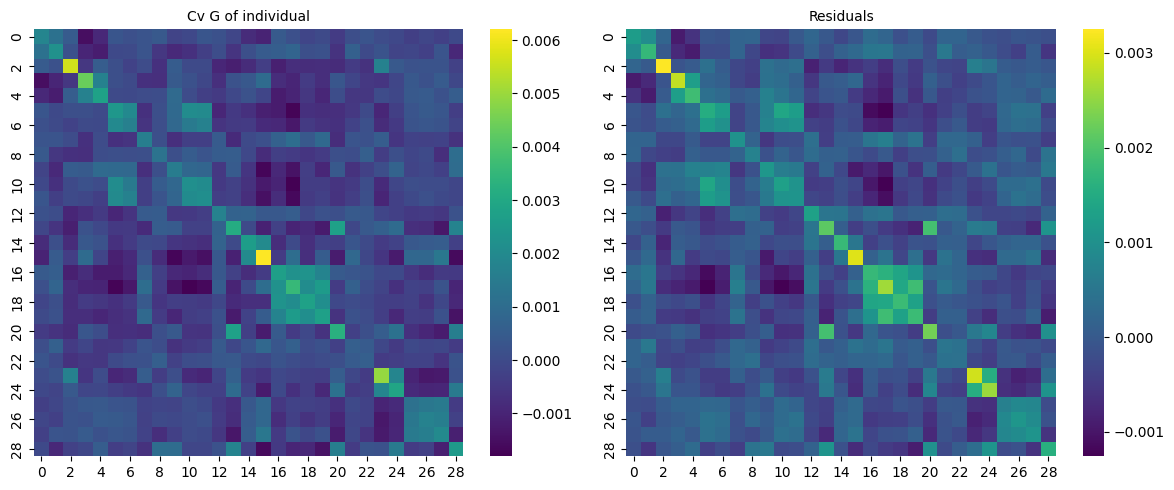

In [14]:
#plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(G_individuals_averaged, cmap='viridis')
plt.title('Cv G of individual', fontsize=10)

plt.subplot(1, 2, 2)
sns.heatmap(residual_cov_mean, cmap='viridis')
plt.title('Residuals', fontsize=10)
plt.tight_layout()
